# ResNet50 experiments for MURA

Train uses `train/` with an internal 10% validation split by study. The original `valid/` folder is kept as the final test dataset.

This notebook compares ResNet50 fine-tuning strategies with a shared training/evaluation loop and model-specific optimizer schedules.

In [7]:
from pathlib import Path
import os
import random
import sys
import time

# Keeps Matplotlib cache/config writable in notebook/container environments. Safe to remove locally.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, auc
from sklearn.model_selection import GroupShuffleSplit
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights, ResNet101_Weights
from tqdm import tqdm
from IPython.display import display, clear_output

def in_colab():
    try:
        import google.colab  # noqa
        print("is in colab")
        return True
    except ImportError:
        return False

if in_colab():
    from google.colab import drive
    try:
      drive.mount('/content/drive')
    except:
      pass
    !cp "/content/drive/MyDrive/Project2025/MURA-v1.1-resized-224x224.zip" "."
    !unzip -q "MURA-v1.1-resized-224x224.zip"

def prefix_path(path: Path|str) -> Path:
    if in_colab():
        return Path("/content/drive/MyDrive/Project2025/") / path
    else:
        return Path(".") / path

SEED = 42
DATA_ROOT = Path("MURA-v1.1-resized-224x224")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "valid"
MODEL_DIR = prefix_path("models")
MODEL_DIR.mkdir(exist_ok=True)


IMG_SIZE = 224
BATCH_SIZE =  750 if in_colab() else 32
NUM_WORKERS = 14 if in_colab() else 0  # In notebooks this is usually more stable; increase on Linux if needed.
EPOCHS = 30
LR = 3e-4
if in_colab():
    LR = 2e-3
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = True
print(f"batch_size: {BATCH_SIZE} learning rate: {LR}")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

batch_size: 32 learning rate: 0.0003
device: cuda


In [8]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}


def label_from_path(path: Path) -> int:
    study_name = path.parent.name.lower()
    if "positive" in study_name:
        return 1
    if "negative" in study_name:
        return 0
    raise ValueError(f"Cannot infer label from study folder: {path.parent}")


def study_from_path(path: Path) -> str:
    # Example: train/XR_HAND/patient10502/study1_positive/image1.png
    return str(path.parent)


def anatomy_from_path(path: Path) -> str:
    return path.parts[-4]


def build_mura_frame(split_dir: Path) -> pd.DataFrame:
    if not split_dir.exists():
        raise FileNotFoundError(f"Missing split directory: {split_dir.resolve()}")

    rows = []
    paths = sorted(split_dir.rglob("*"))
    for path in tqdm(paths, total=len(paths), desc="Processing paths"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            rows.append(
                {
                    "path": path,
                    "label": label_from_path(path),
                    "study": study_from_path(path),
                    "anatomy": anatomy_from_path(path),
                }
            )

    if not rows:
        raise RuntimeError(f"No images found under {split_dir.resolve()}")

    return pd.DataFrame(rows)


train_full_df = build_mura_frame(TRAIN_DIR)
test_df = build_mura_frame(TEST_DIR)

print("train images:", len(train_full_df), "studies:", train_full_df.study.nunique())
print("test images:", len(test_df), "studies:", test_df.study.nunique())
display(train_full_df.groupby(["anatomy", "label"]).size().unstack(fill_value=0))
display(test_df.groupby(["anatomy", "label"]).size().unstack(fill_value=0))

Processing paths: 100%|██████████| 5521/5521 [00:00<00:00, 165107.00it/s]

train images: 36808 studies: 13457
test images: 3197 studies: 1199


label,0,1
anatomy,,
XR_ELBOW,2925,2006
XR_FINGER,3138,1968
XR_FOREARM,1164,661
XR_HAND,4059,1484
XR_HUMERUS,673,599
XR_SHOULDER,4211,4168
XR_WRIST,5765,3987


label,0,1
anatomy,,
XR_ELBOW,235,230
XR_FINGER,214,247
XR_FOREARM,150,151
XR_HAND,271,189
XR_HUMERUS,148,140
XR_SHOULDER,285,278
XR_WRIST,364,295


In [9]:
display(train_full_df.sample(5))
display(test_df.sample(5))

,path,label,study,anatomy
263,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,0,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,XR_ELBOW
14766,MURA-v1.1-resized-224x224/train/XR_HAND/patien...,0,MURA-v1.1-resized-224x224/train/XR_HAND/patien...,XR_HAND
5100,MURA-v1.1-resized-224x224/train/XR_FINGER/pati...,1,MURA-v1.1-resized-224x224/train/XR_FINGER/pati...,XR_FINGER
36540,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,0,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,XR_WRIST
24129,MURA-v1.1-resized-224x224/train/XR_SHOULDER/pa...,0,MURA-v1.1-resized-224x224/train/XR_SHOULDER/pa...,XR_SHOULDER


,path,label,study,anatomy
729,MURA-v1.1-resized-224x224/valid/XR_FINGER/pati...,1,MURA-v1.1-resized-224x224/valid/XR_FINGER/pati...,XR_FINGER
1315,MURA-v1.1-resized-224x224/valid/XR_HAND/patien...,0,MURA-v1.1-resized-224x224/valid/XR_HAND/patien...,XR_HAND
1938,MURA-v1.1-resized-224x224/valid/XR_HUMERUS/pat...,0,MURA-v1.1-resized-224x224/valid/XR_HUMERUS/pat...,XR_HUMERUS
726,MURA-v1.1-resized-224x224/valid/XR_FINGER/pati...,1,MURA-v1.1-resized-224x224/valid/XR_FINGER/pati...,XR_FINGER
1933,MURA-v1.1-resized-224x224/valid/XR_HUMERUS/pat...,0,MURA-v1.1-resized-224x224/valid/XR_HUMERUS/pat...,XR_HUMERUS


In [10]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
train_idx, internal_val_idx = next(
    splitter.split(train_full_df, y=train_full_df["label"], groups=train_full_df["study"])
)

train_df = train_full_df.iloc[train_idx].reset_index(drop=True)
internal_val_df = train_full_df.iloc[internal_val_idx].reset_index(drop=True)

print("fit train images:", len(train_df), "studies:", train_df.study.nunique())
print("internal val images:", len(internal_val_df), "studies:", internal_val_df.study.nunique())
print("study leakage:", len(set(train_df.study) & set(internal_val_df.study)))

display(pd.DataFrame({
    "train": train_df.label.value_counts(normalize=True).sort_index(),
    "internal_val": internal_val_df.label.value_counts(normalize=True).sort_index(),
    "test": test_df.label.value_counts(normalize=True).sort_index(),
}).rename(index={0: "negative", 1: "positive"}))

fit train images: 33143 studies: 12111
internal val images: 3665 studies: 1346
study leakage: 0


,train,internal_val,test
label,,,
negative,0.592946,0.62292,0.521426
positive,0.407054,0.37708,0.478574


In [11]:
train_tfms_no_aug = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=ResNet50_Weights.DEFAULT.transforms().mean, std=ResNet50_Weights.DEFAULT.transforms().std),
    ]
)
train_tfms = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.90, 1.10)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=7),
        transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.12, contrast=0.18),
        transforms.ToTensor(),
        transforms.Normalize(mean=ResNet50_Weights.DEFAULT.transforms().mean, std=ResNet50_Weights.DEFAULT.transforms().std),
    ]
)
train_tfms_resnet101 = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.90, 1.10)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=7),
        transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.12, contrast=0.18),
        transforms.ToTensor(),
        transforms.Normalize(mean=ResNet101_Weights.DEFAULT.transforms().mean, std=ResNet101_Weights.DEFAULT.transforms().std),
    ]
)

eval_tfms = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=ResNet50_Weights.DEFAULT.transforms().mean, std=ResNet50_Weights.DEFAULT.transforms().std),
    ]
)


eval_tfms_101 = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=ResNet101_Weights.DEFAULT.transforms().mean, std=ResNet101_Weights.DEFAULT.transforms().std),
    ]
)


class MuraImageDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row.path).convert("L")
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(row.label, dtype=torch.float32)
        return image, label


train_ds = MuraImageDataset(train_df, train_tfms)
train_ds_101 = MuraImageDataset(train_df, train_tfms_resnet101)
train_ds_no_aug = MuraImageDataset(train_df, train_tfms_no_aug)
internal_val_ds = MuraImageDataset(internal_val_df, eval_tfms)
internal_val_ds_101 = MuraImageDataset(internal_val_df, eval_tfms_101)
test_ds = MuraImageDataset(test_df, eval_tfms)
test_ds_101 = MuraImageDataset(test_df, eval_tfms_101)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
train_loader_101 = DataLoader(train_ds_101, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
train_loader_no_aug = DataLoader(train_ds_no_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
internal_val_loader = DataLoader(internal_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
internal_val_loader_101 = DataLoader(internal_val_ds_101, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader_101 = DataLoader(test_ds_101, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape, yb[:8].tolist())

torch.Size([32, 3, 224, 224]) torch.Size([32]) [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


[8894, 9976, 17409, 9197, 26239, 19888, 19385, 17835]

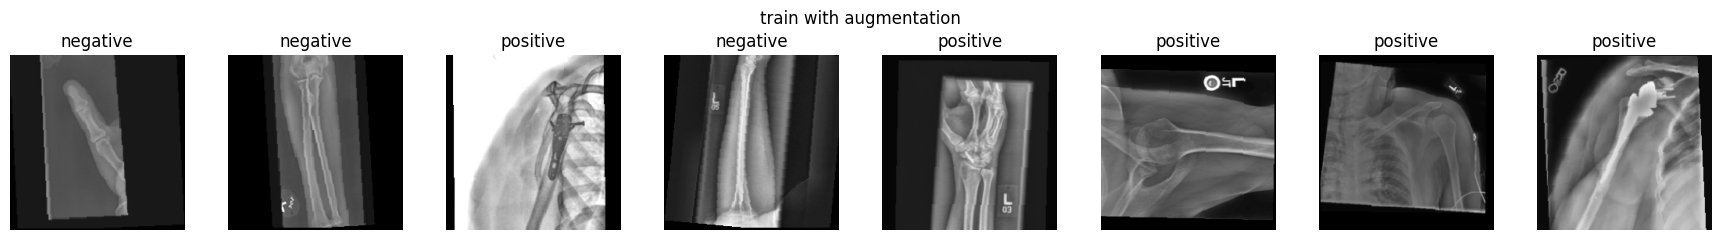

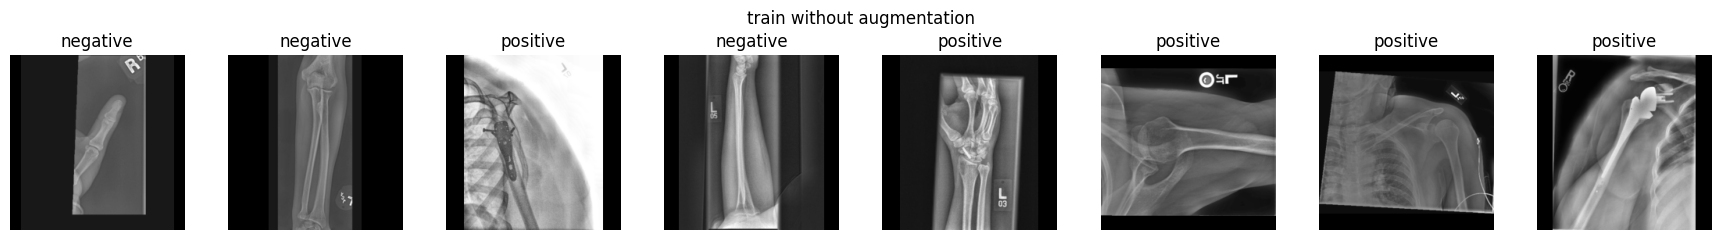

In [12]:
def _denormalize_resnet_image(image):
    mean = torch.tensor(ResNet50_Weights.DEFAULT.transforms().mean).view(3, 1, 1)
    std = torch.tensor(ResNet50_Weights.DEFAULT.transforms().std).view(3, 1, 1)
    return (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)


def get_deterministic_batch(dataset, indices, seed=SEED):
    rng_state = torch.random.get_rng_state()
    images, labels = [], []
    try:
        for idx in indices:
            torch.manual_seed(seed + int(idx))
            image, label = dataset[int(idx)]
            images.append(image)
            labels.append(label)
    finally:
        torch.random.set_rng_state(rng_state)
    return torch.stack(images), torch.stack(labels)


def make_batch_indices(dataset, n=8, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return torch.randperm(len(dataset), generator=generator)[:n].tolist()


def show_batch(dataset, indices=None, n=8, seed=SEED, title=None):
    if indices is None:
        indices = make_batch_indices(dataset, n=n, seed=seed)
    images, labels = get_deterministic_batch(dataset, indices, seed=seed)

    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.4))
    if n == 1:
        axes = [axes]
    for ax, image, label in zip(axes, images, labels):
        ax.imshow(_denormalize_resnet_image(image))
        ax.set_title("positive" if int(label.item()) == 1 else "negative")
        ax.axis("off")
    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    return indices


batch_indices = make_batch_indices(train_ds, n=8, seed=SEED)
show_batch(train_ds, indices=batch_indices, seed=SEED, title="train with augmentation")
show_batch(train_ds_no_aug, indices=batch_indices, seed=SEED, title="train without augmentation")

In [13]:
def build_model(model: str = "resnet50", use_pretrained: bool = True) -> nn.Module:
    weights = None
    if use_pretrained:
        if model == "resnet50":
            weights = ResNet50_Weights.DEFAULT
        elif model == "resnet101":
            weights = ResNet101_Weights.DEFAULT
    try:
        if model == "resnet50":
            model = models.resnet50(weights=weights)
        elif model == "resnet101":
            model = models.resnet101(weights=weights)
        else:
            raise ValueError(f"Unsupported model: {model}")
    except Exception as exc:
        print(f"Could not load pretrained {model} weights ({exc}); using random initialization.")
        if model == "resnet50":
            model = models.resnet50(weights=None)
        elif model == "resnet101":
            model = models.resnet101(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
    return model


pos_count = train_df.label.sum()
neg_count = len(train_df) - pos_count
pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("pos_weight:", round(float(pos_weight.item()), 3))

pos_weight: 1.457


In [14]:
# model_101 = build_model("resnet101", use_pretrained=USE_PRETRAINED)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /home/rubar01/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:07<00:00, 25.5MB/s] 


In [ ]:
# model_101_paramnames = list(map(lambda x: x[0], list(model_101.named_children())))

# model_101_backbone = model_101_paramnames[:-1]  # Exclude the final fully connected layer
# model_101_head = [model_101_paramnames[-1]]  # The final fully connected layer

In [30]:
# print(list(map(lambda x: f".{x}", model_101_backbone)), list(map(lambda x: f".{x}", model_101_head)))

['.conv1', '.bn1', '.relu', '.maxpool', '.layer1', '.layer2', '.layer3', '.layer4', '.avgpool'] ['.fc']


In [ ]:
prefixes_by_model = {
    "resnet50": {
        "backbone": ("conv1.", "bn1.", "layer1.", "layer2.", "layer3.", "layer4."),
        "head": ("fc.",),
    },
    "resnet101": {
        "backbone": ("conv1.", "bn1.", "layer1.", "layer2.", "layer3.", "layer4."),
        "head": ("fc.",),
    },
}

In [ ]:
def set_trainable_prefixes(model: nn.Module, trainable_prefixes) -> None:
    trainable_prefixes = tuple(trainable_prefixes)
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith(trainable_prefixes)


def make_optimizer(model: nn.Module, group_specs) -> torch.optim.Optimizer:
    param_groups = []
    used_param_ids = set()

    for spec in group_specs:
        prefixes = tuple(spec["prefixes"])
        params = []
        for name, param in model.named_parameters():
            if not param.requires_grad or id(param) in used_param_ids:
                continue
            if name.startswith(prefixes):
                params.append(param)
                used_param_ids.add(id(param))
        if params:
            param_groups.append({"params": params, "lr": spec["lr"], "name": spec["name"]})

    if not param_groups:
        raise ValueError("Optimizer has no trainable parameters. Check experiment config.")

    return torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)


def optimizer_signature(group_specs):
    return tuple((spec["name"], tuple(spec["prefixes"]), float(spec["lr"])) for spec in group_specs)


def lr_summary(optimizer: torch.optim.Optimizer) -> str:
    return ", ".join(f"{group.get('name', i)}={group['lr']:.2e}" for i, group in enumerate(optimizer.param_groups))


def epoch_group_specs(model: nn.Module, config: dict, epoch: int):
    strategy = config["strategy"]
    HEAD_PREFIXES = prefixes_by_model[config["model"]]["head"]
    BACKBONE_PREFIXES = prefixes_by_model[config["model"]]["backbone"]
    RESNET_STAGE_PREFIXES = (*BACKBONE_PREFIXES, *HEAD_PREFIXES)
    match strategy:
        case "freeze_unfreeze_lr_drop":
            if epoch <= config["freeze_epochs"]:
                set_trainable_prefixes(model, HEAD_PREFIXES)
                return [{"name": "head", "prefixes": HEAD_PREFIXES, "lr": config["head_lr"]}]

            set_trainable_prefixes(model, RESNET_STAGE_PREFIXES)
            if isinstance(config["unfreeze_lr"], dict):
                return [
                    {"name": "backbone", "prefixes": BACKBONE_PREFIXES, "lr": config["unfreeze_lr"]["backbone"]},
                    {"name": "head", "prefixes": HEAD_PREFIXES, "lr": config["unfreeze_lr"]["head"]},
                ]
            else:
                return [{"name": "all", "prefixes": RESNET_STAGE_PREFIXES, "lr": config["unfreeze_lr"]}]

        case "differential_lr":
            set_trainable_prefixes(model, RESNET_STAGE_PREFIXES)
            return [
                {"name": "backbone", "prefixes": BACKBONE_PREFIXES, "lr": config["backbone_lr"]},
                {"name": "head", "prefixes": HEAD_PREFIXES, "lr": config["head_lr"]},
            ]

        case "gradual_unfreeze":
            active_backbone_prefixes = []
            for start_epoch, prefixes in config["unfreeze_schedule"]:
                if epoch >= start_epoch:
                    active_backbone_prefixes.extend(prefixes)
            active_prefixes = tuple(active_backbone_prefixes) + HEAD_PREFIXES
            set_trainable_prefixes(model, active_prefixes)

            specs = []
            if active_backbone_prefixes:
                specs.append({"name": "active_backbone", "prefixes": tuple(active_backbone_prefixes), "lr": config["backbone_lr"]})
            specs.append({"name": "head", "prefixes": HEAD_PREFIXES, "lr": config["head_lr"]})
            return specs

        case "discriminative_lr":
            set_trainable_prefixes(model, RESNET_STAGE_PREFIXES)
            return config["stage_lrs"]
        case _:
            raise ValueError(f"Unknown strategy: {strategy}")

def pr_aux_score(y_true, y_prob):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    return auc(recall, precision)

def binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_pred = (y_prob >= threshold).astype(np.int64)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "kappa": cohen_kappa_score(y_true, y_pred),
    }
    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
        metrics["pr_auc"] = pr_aux_score(y_true, y_prob)
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan
    metrics["metric"] = 0.4 * metrics.get('kappa', 0) + 0.4 * metrics.get("pr_auc", 0) + 0.2 * metrics.get("roc_auc", 0)

    return metrics


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    desc=None,
    position=1,
    progress_bar=None,
    progress_epoch=None,
    progress_phase=None,
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_targets = []
    all_probs = []

    iterator = loader
    if progress_bar is None:
        iterator = tqdm(
            loader,
            desc=desc,
            position=position,
            leave=False,
            dynamic_ncols=True,
            file=sys.stdout,
        )
    elif progress_phase is not None:
        progress_bar.set_postfix(epoch=progress_epoch, phase=progress_phase, refresh=True)

    with torch.set_grad_enabled(is_train):
        for images, targets in iterator:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            logits = model(images).squeeze(1)
            loss = criterion(logits, targets)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy().tolist())
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
            if progress_bar is not None:
                progress_bar.update(1)

    avg_loss = total_loss / len(loader.dataset)
    metrics = binary_metrics(all_targets, all_probs)
    metrics["loss"] = avg_loss
    return metrics


def format_metrics(prefix, metrics):
    return (
        f"{prefix} loss={metrics['loss']:.4f} "
        f"acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} "
        f"auc={metrics['roc_auc']:.4f} kappa={metrics['kappa']:.4f}"
    )

In [ ]:

EXPERIMENTS = [
    # {
    #     "name": "resnet_50_aug",
    #     "title": "Resnet 50 Freeze -> Unfreeze + LR drop",
    #     "strategy": "freeze_unfreeze_lr_drop",
    #     "train_loader": train_loader,
    #     "best_path": MODEL_DIR / "resnet50_mura_best.pt",
    #     "history_path": MODEL_DIR / "resnet_50_aug_training_history.csv",
    #     "epochs": EPOCHS,
    #     "freeze_epochs": 1,
    #     "head_lr": LR,
    #     "unfreeze_lr": LR * 0.3,
    #     "batch_size": BATCH_SIZE,
    #     "model": "resnet50",
    #     "val_loader": internal_val_loader,
    # },
    {
        "name": "resnet_50_no_aug",
        "title": "Resnet 50 No Aug Freeze -> Unfreeze + LR drop",
        "strategy": "freeze_unfreeze_lr_drop",
        "train_loader": train_loader_no_aug,
        "best_path": MODEL_DIR / "resnet50_mura_no_aug_best.pt",
        "history_path": MODEL_DIR / "resnet_50_no_aug_training_history.csv",
        "epochs": EPOCHS,
        "freeze_epochs": 1,
        "head_lr": LR,
        "unfreeze_lr": LR * 0.3,
        "batch_size": BATCH_SIZE,
        "model": "resnet50",
        "val_loader": internal_val_loader,
    },
    {
        "name": "resnet_101_aug",
        "title": "Resnet 101 Freeze -> Unfreeze + LR drop",
        "strategy": "freeze_unfreeze_lr_drop",
        "train_loader": train_loader_101,
        "best_path": MODEL_DIR / "resnet101_mura_best.pt",
        "history_path": MODEL_DIR / "resnet_101_aug_training_history.csv",
        "epochs": EPOCHS,
        "freeze_epochs": 3,
        "head_lr": 1e-3,
        "unfreeze_lr": {
            "backbone": 1e-5,
            "head": 3e-4,
        },
        "batch_size": 256,
        "model": "resnet101",
        "val_loader": internal_val_loader_101,
    },
    # {
    #     "name": "resnet_50_aug_differential_lr",
    #     "title": "Resnet 50 Differential LR: low backbone LR, high head LR",
    #     "strategy": "differential_lr",
    #     "train_loader": train_loader,
    #     "best_path": MODEL_DIR / "resnet50_mura_differential_lr_best.pt",
    #     "history_path": MODEL_DIR / "resnet_50_aug_differential_lr_training_history.csv",
    #     "epochs": EPOCHS,
    #     "backbone_lr": LR * 0.1,
    #     "head_lr": LR,
    #     "batch_size": BATCH_SIZE,
    #     "model": "resnet50",
    #     "val_loader": internal_val_loader,
    # },
    # {
    #     "name": "resnet_50_aug_gradual_unfreeze",
    #     "title": "Resnet 50 Gradual unfreezing by ResNet stage",
    #     "strategy": "gradual_unfreeze",
    #     "train_loader": train_loader,
    #     "best_path": MODEL_DIR / "resnet50_mura_gradual_unfreeze_best.pt",
    #     "history_path": MODEL_DIR / "resnet_50_aug_gradual_unfreeze_training_history.csv",
    #     "epochs": EPOCHS,
    #     "backbone_lr": LR * 0.1,
    #     "head_lr": LR,
    #     "unfreeze_schedule": [
    #         (2, ("layer4.",)),
    #         (3, ("layer3.",)),
    #         (4, ("layer2.",)),
    #         (5, ("layer1.",)),
    #         (6, ("conv1.", "bn1.")),
    #     ],
    #     "batch_size": BATCH_SIZE,
    #     "model": "resnet50",
    #     "val_loader": internal_val_loader,
    # },
    # {
    #     "name": "resnet_50_aug_discriminative_lr",
    #     "title": "Resnet 50 Discriminative LR: deeper layers get higher LR",
    #     "strategy": "discriminative_lr",
    #     "train_loader": train_loader,
    #     "best_path": MODEL_DIR / "resnet50_mura_discriminative_lr_best.pt",
    #     "history_path": MODEL_DIR / "resnet_50_aug_discriminative_lr_training_history.csv",
    #     "epochs": EPOCHS,
    #     "stage_lrs": [
    #         {"name": "stem", "prefixes": ("conv1.", "bn1."), "lr": LR * 0.02},
    #         {"name": "layer1", "prefixes": ("layer1.",), "lr": LR * 0.05},
    #         {"name": "layer2", "prefixes": ("layer2.",), "lr": LR * 0.10},
    #         {"name": "layer3", "prefixes": ("layer3.",), "lr": LR * 0.30},
    #         {"name": "layer4", "prefixes": ("layer4.",), "lr": LR * 0.60},
    #         {"name": "head", "prefixes": ("fc.",), "lr": LR},
    #     ],
    #     "batch_size": BATCH_SIZE,
    #     "model": "resnet50",
    #     "val_loader": internal_val_loader,
    # },
]


def resume_checkpoint_path(config: dict) -> Path:
    return MODEL_DIR / f"checkpoint_{config['name']}.pt"


def load_torch_checkpoint(path: Path) -> dict:
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def checkpoint_model_state(checkpoint: dict):
    return checkpoint.get("model_state", checkpoint.get("model_state_dict"))


def load_history(config: dict, checkpoint: dict | None = None) -> pd.DataFrame:
    if config["history_path"].exists():
        history_df = pd.read_csv(config["history_path"])
    elif checkpoint is not None and checkpoint.get("history"):
        history_df = pd.DataFrame(checkpoint["history"])
    else:
        history_df = pd.DataFrame()

    if not history_df.empty and "model" not in history_df.columns:
        history_df.insert(0, "model", config["name"])
    return history_df


def last_finished_epoch(history_df: pd.DataFrame, checkpoint: dict | None = None) -> int:
    history_epoch = int(history_df["epoch"].max()) if not history_df.empty and "epoch" in history_df else 0
    checkpoint_epoch = int(checkpoint.get("epoch", 0)) if checkpoint is not None else 0
    return max(history_epoch, checkpoint_epoch)


def best_weighted_metric_from_history(*checkpoints) -> float:
    values = []
    for checkpoint in checkpoints:
        if checkpoint is not None and checkpoint.get("best_val_metric") is not None:
            values.append(float(checkpoint["best_val_metric"]))
    return max(values) if values else -1.0


def make_scheduler(optimizer: torch.optim.Optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)


def save_resume_checkpoint(
    config: dict,
    epoch: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    history: list[dict],
    current_signature,
    best_val_metric: float,
) -> None:
    torch.save(
        {
            "experiment": config["name"],
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "optimizer_signature": current_signature,
            "best_val_metric": best_val_metric,
            "history": history,
            "config": {
                "name": config["name"],
                "strategy": config["strategy"],
                "data_root": str(DATA_ROOT),
                "img_size": IMG_SIZE,
                "use_pretrained": USE_PRETRAINED,
            },
        },
        resume_checkpoint_path(config),
    )


def plot_training_history(history_df: pd.DataFrame, title: str) -> None:
    if history_df.empty:
        print(f"No history to plot for {title}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df.epoch, history_df.train_loss, label="train")
    axes[0].plot(history_df.epoch, history_df.val_loss, label="internal_val")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history_df.epoch, history_df.train_kappa, label="train_kappa")
    axes[1].plot(history_df.epoch, history_df.val_kappa, label="internal_val_kappa")
    axes[1].plot(history_df.epoch, history_df.val_roc_auc, label="internal_val_auc")
    axes[1].set_title(f"{title}: validation metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()


def restore_training_checkpoint(model: nn.Module, config: dict, checkpoint: dict):
    resume_epoch = int(checkpoint["epoch"])
    model.load_state_dict(checkpoint_model_state(checkpoint))

    group_specs = epoch_group_specs(model, config, resume_epoch)
    optimizer = make_optimizer(model, group_specs)
    scheduler = make_scheduler(optimizer)
    current_signature = checkpoint.get("optimizer_signature", optimizer_signature(group_specs))

    try:
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        scheduler.load_state_dict(checkpoint["scheduler_state"])
    except (KeyError, ValueError) as exc:
        print(f"{config['name']}: optimizer/scheduler state was not restored ({exc}); continuing with fresh state.")
        optimizer = None
        scheduler = None
        current_signature = None

    return optimizer, scheduler, current_signature, resume_epoch + 1


def train_or_load_experiment(config: dict) -> dict:
    model = build_model(config["model"], use_pretrained=USE_PRETRAINED).to(device)
    best_path = config["best_path"]
    resume_path = resume_checkpoint_path(config)

    best_checkpoint = load_torch_checkpoint(best_path) if best_path.exists() else None
    resume_checkpoint = load_torch_checkpoint(resume_path) if resume_path.exists() else None
    history_df = load_history(config, resume_checkpoint or best_checkpoint)

    if best_checkpoint is None and resume_checkpoint is None and not history_df.empty:
        print(f"{config['name']}: found history CSV without a checkpoint; starting from scratch.")
        history_df = pd.DataFrame()

    last_epoch = last_finished_epoch(history_df, resume_checkpoint)

    if resume_checkpoint is None and best_checkpoint is not None and history_df.empty:
        model.load_state_dict(best_checkpoint["model_state_dict"])
        print(
            f"{config['name']}: loaded legacy best checkpoint from epoch "
            f"{best_checkpoint.get('epoch', '?')} with val_kappa={best_checkpoint.get('best_val_kappa', float('nan')):.4f}"
        )
        plot_training_history(history_df, config["title"])
        return {"model": model, "history": history_df, "checkpoint": best_checkpoint, "trained": False}

    if last_epoch >= config["epochs"]:
        checkpoint_for_eval = best_checkpoint or resume_checkpoint
        if checkpoint_for_eval is not None:
            model.load_state_dict(checkpoint_model_state(checkpoint_for_eval))
        print(f"{config['name']}: training already finished at epoch {last_epoch}/{config['epochs']}.")
        display(history_df)
        plot_training_history(history_df, config["title"])
        return {"model": model, "history": history_df, "checkpoint": checkpoint_for_eval, "trained": False}

    optimizer = None
    scheduler = None
    current_signature = None
    start_epoch = 1

    if resume_checkpoint is not None:
        optimizer, scheduler, current_signature, start_epoch = restore_training_checkpoint(model, config, resume_checkpoint)
        if not history_df.empty:
            history_df = history_df[history_df["epoch"] <= int(resume_checkpoint["epoch"])].reset_index(drop=True)
        print(f"{config['name']}: resumed from {resume_path} at epoch {start_epoch}/{config['epochs']}.")
    elif best_checkpoint is not None and not history_df.empty:
        best_epoch = int(best_checkpoint.get("epoch", last_epoch))
        model.load_state_dict(best_checkpoint["model_state_dict"])
        if not history_df.empty:
            history_df = history_df[history_df["epoch"] <= best_epoch].reset_index(drop=True)
        start_epoch = best_epoch + 1
        print(f"{config['name']}: continuing from best checkpoint epoch {best_epoch} with fresh optimizer state.")

    history = history_df.to_dict("records") if not history_df.empty else []
    best_val_metric = best_weighted_metric_from_history(best_checkpoint, resume_checkpoint)

    total_progress_steps = (config["epochs"] - start_epoch + 1) * (
        len(config["train_loader"]) + len(internal_val_loader)
    )
    progress_bar = tqdm(
        total=total_progress_steps,
        desc=f"Training {config['name']}",
        dynamic_ncols=True,
        file=sys.stdout,
    )

    for epoch in range(start_epoch, config["epochs"] + 1):
        start = time.time()
        group_specs = epoch_group_specs(model, config, epoch)
        signature = optimizer_signature(group_specs)
        if optimizer is None or scheduler is None or signature != current_signature:
            optimizer = make_optimizer(model, group_specs)
            scheduler = make_scheduler(optimizer)
            current_signature = signature

        train_metrics = run_epoch(
            model,
            config["train_loader"],
            criterion,
            optimizer=optimizer,
            progress_bar=progress_bar,
            progress_epoch=epoch,
            progress_phase="train",
        )
        val_metrics = run_epoch(
            model,
            config.get('val_loader', internal_val_loader),
            criterion,
            optimizer=None,
            progress_bar=progress_bar,
            progress_epoch=epoch,
            progress_phase="internal_val",
        )
        scheduler.step(val_metrics["kappa"])

        row = {
            "model": config["name"],
            "epoch": epoch,
            "lr": max(group["lr"] for group in optimizer.param_groups),
            "lr_groups": lr_summary(optimizer),
        }
        row.update({f"train_{k}": v for k, v in train_metrics.items()})
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        history.append(row)

        history_df = pd.DataFrame(history)
        history_df.to_csv(config["history_path"], index=False)
        # clear_output(wait=True)
        print(config["title"])
        display(history_df)
        # "0.4*kappa + 0.4*pr_auc + 0.2*roc_auc"
        cumulative_metric = val_metrics.get("metric", 0.0)

        if cumulative_metric > best_val_metric:
            best_val_metric = cumulative_metric
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "best_val_metric": best_val_metric,
                    "history": history,
                    "config": {
                        "name": config["name"],
                        "strategy": config["strategy"],
                        "data_root": str(DATA_ROOT),
                        "img_size": IMG_SIZE,
                        "use_pretrained": USE_PRETRAINED,
                    },
                },
                best_path,
            )

        save_resume_checkpoint(
            config=config,
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            history=history,
            current_signature=current_signature,
            best_val_metric=best_val_metric,
        )

        elapsed = time.time() - start
        print(
            f"{config['name']} epoch {epoch:02d}/{config['epochs']} ({elapsed:.1f}s) | "
            + format_metrics("train", train_metrics)
            + " | "
            + format_metrics("internal_val", val_metrics)
            + f" | lr: {lr_summary(optimizer)}"
        )
        print(f"resume checkpoint: {resume_path}")
        plot_training_history(history_df, config["title"])

    progress_bar.close()

    final_checkpoint = load_torch_checkpoint(best_path) if best_path.exists() else load_torch_checkpoint(resume_path)
    model.load_state_dict(checkpoint_model_state(final_checkpoint))
    history_df = pd.DataFrame(history)
    return {"model": model, "history": history_df, "checkpoint": final_checkpoint, "trained": True}


experiment_results = {}
for experiment_config in EXPERIMENTS:
    experiment_results[experiment_config["name"]] = train_or_load_experiment(experiment_config)

primary_model_name = EXPERIMENTS[0]["name"]
model = experiment_results[primary_model_name]["model"]
history_df = experiment_results[primary_model_name]["history"]

NameError: name 'train_loader' is not defined

In [ ]:
image_level_rows = []
for experiment_config in EXPERIMENTS:
    name = experiment_config["name"]
    model_for_eval = experiment_results[name]["model"]
    test_metrics = run_epoch(model_for_eval, test_loader, criterion, optimizer=None)
    image_level_rows.append({"model": name, "split": "test", **test_metrics})
    print(f"{name}: " + format_metrics("test", test_metrics))

image_level_metrics_df = pd.DataFrame(image_level_rows)
display(image_level_metrics_df)
image_level_metrics_df.to_csv(MODEL_DIR / "resnet_50_image_level_metrics.csv", index=False)

In [ ]:
history_frames = [result["history"] for result in experiment_results.values() if not result["history"].empty]
all_history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()

if not all_history_df.empty:
    display(all_history_df)
    for experiment_config in EXPERIMENTS:
        name = experiment_config["name"]
        model_history = all_history_df[all_history_df["model"] == name]
        plot_training_history(model_history, experiment_config["title"])
else:
    print("No training history found yet.")

In [ ]:
if not all_history_df.empty:
    all_history_df.to_csv(MODEL_DIR / "resnet_50_all_training_history.csv", index=False)

## Cohen's kappa на уровне исследований

Вероятности по снимкам усредняются внутри каждого `study`, затем Cohen's kappa считается по исследованиям для train, internal_val и test.


In [ ]:
def predict_study_level(
        model_name: str,
        split_name: str,
        model,
        frame: pd.DataFrame,
        threshold: float = 0.5,
        batch_size: int = BATCH_SIZE,
        resnet_version: str = "resnet50"
    ):
    eval_tfms_to_use = None
    match resnet_version:
        case "resnet50":
            eval_tfms_to_use = eval_tfms
        case "resnet101":
            eval_tfms_to_use = eval_tfms_101
        case _:
            raise ValueError(f"Unsupported ResNet version: {resnet_version}")
    eval_ds = MuraImageDataset(frame, eval_tfms_to_use)
    eval_loader = DataLoader(
        eval_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    probs = []
    with torch.no_grad():
        for images, _ in tqdm(eval_loader, leave=True, desc=f"Evaluating {model_name} on {split_name}"):
            images = images.to(device, non_blocking=True)
            logits = model(images).squeeze(1)
            probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())

    image_predictions = frame.reset_index(drop=True).copy()
    image_predictions["prob"] = probs
    image_predictions["pred"] = (image_predictions["prob"] >= threshold).astype(int)

    study_predictions = (
        image_predictions
        .groupby("study", as_index=False)
        .agg(
            label=("label", "first"),
            anatomy=("anatomy", "first"),
            n_images=("path", "size"),
            prob=("prob", "mean"),
        )
    )
    study_predictions["pred"] = (study_predictions["prob"] >= threshold).astype(int)
    return study_predictions

# Подбор порогов

In [ ]:
def find_best_study_threshold(
        name: str,
        model,
        frame: pd.DataFrame,
        thresholds=None) -> tuple[float, pd.DataFrame]:
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, num=20)
    print(f"searching best threshold for study-level predictions for model {name}...")
    rows = []
    best_threshold = None
    best_kappa = -1.0
    for threshold in tqdm(thresholds, desc=f"Searching best threshold for {name}"):
        resnet_version = next(config["model"] for config in EXPERIMENTS if config["name"] == name)
        study_level_pred_val = predict_study_level(name, f"internal_val with threshold {threshold:.2f}", model, frame, threshold=threshold, resnet_version=resnet_version)
        kappa = cohen_kappa_score(study_level_pred_val["label"], study_level_pred_val["pred"])
        rows.append({"threshold": threshold, "kappa": kappa})
        if kappa > best_kappa:
            best_kappa = kappa
            best_threshold = threshold

    return best_threshold, pd.DataFrame(rows)


threshold_search_results = {}
threshold_rows = []
thresholds = np.linspace(0.1, 0.9, num=20)

for experiment_config in EXPERIMENTS:
    name = experiment_config["name"]
    best_threshold, threshold_kappa_df = find_best_study_threshold(
        name,
        experiment_results[name]["model"],
        internal_val_df,
        thresholds=thresholds,
    )
    threshold_kappa_df.insert(0, "model", name)
    threshold_search_results[name] = {
        "best_threshold": best_threshold,
        "threshold_kappa_df": threshold_kappa_df,
    }
    threshold_rows.append(
        {
            "model": name,
            "best_threshold": best_threshold,
            "best_internal_val_kappa": threshold_kappa_df["kappa"].max(),
        }
    )
    print(f"{name}: best threshold={best_threshold:.2f}, internal_val study kappa={threshold_kappa_df['kappa'].max():.4f}")

threshold_summary_df = pd.DataFrame(threshold_rows)
threshold_kappa_all_df = pd.concat(
    [item["threshold_kappa_df"] for item in threshold_search_results.values()],
    ignore_index=True,
)

display(threshold_summary_df)
display(threshold_kappa_all_df)
threshold_summary_df.to_csv(MODEL_DIR / "resnet_50_threshold_summary.csv", index=False)
threshold_kappa_all_df.to_csv(MODEL_DIR / "resnet_50_threshold_kappas.csv", index=False)

for name, threshold_df in threshold_kappa_all_df.groupby("model"):
    plt.plot(threshold_df["threshold"], threshold_df["kappa"], marker="o", label=name)
plt.xlabel("threshold")
plt.ylabel("internal_val study-level kappa")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
study_level_predictions = {}
for experiment_config in EXPERIMENTS:
    name = experiment_config["name"]
    model_for_eval = experiment_results[name]["model"]
    threshold = threshold_search_results[name]["best_threshold"]
    study_level_predictions[name] = {
        "train": predict_study_level(name, "train", model_for_eval, train_df, threshold=threshold, resnet_version=experiment_config["model"]),
        "internal_val": predict_study_level(name, "internal_val", model_for_eval, internal_val_df, threshold=threshold, resnet_version=experiment_config["model"]),
        "test": predict_study_level(name, "test", model_for_eval, test_df, threshold=threshold, resnet_version=experiment_config["model"]),
    }

In [ ]:
study_kappa_rows = []
for model_name, model_predictions in study_level_predictions.items():
    threshold = threshold_search_results[model_name]["best_threshold"]
    for split_name, study_pred in model_predictions.items():
        study_kappa_rows.append(
            {
                "model": model_name,
                "split": split_name,
                "anatomy": "all",
                "threshold": threshold,
                "studies": len(study_pred),
                "positive_studies": int(study_pred["label"].sum()),
                "negative_studies": int((study_pred["label"] == 0).sum()),
                "cohen_kappa_by_study": cohen_kappa_score(study_pred["label"], study_pred["pred"]),
                "accuracy_by_study": accuracy_score(study_pred["label"], study_pred["pred"]),
            }
        )
        for anatomy in sorted(study_pred["anatomy"].unique()):
            anatomy_pred = study_pred[study_pred["anatomy"] == anatomy]
            study_kappa_rows.append(
                {
                    "model": model_name,
                    "split": split_name,
                    "anatomy": anatomy,
                    "threshold": threshold,
                    "studies": len(anatomy_pred),
                    "positive_studies": int(anatomy_pred["label"].sum()),
                    "negative_studies": int((anatomy_pred["label"] == 0).sum()),
                    "cohen_kappa_by_study": cohen_kappa_score(anatomy_pred["label"], anatomy_pred["pred"]),
                    "accuracy_by_study": accuracy_score(anatomy_pred["label"], anatomy_pred["pred"]),
                }
            )

study_kappa_df = pd.DataFrame(study_kappa_rows)
display(study_kappa_df)

study_kappa_df.to_csv(MODEL_DIR / "resnet_50_study_level_kappa.csv", index=False)
for model_name, model_predictions in study_level_predictions.items():
    for split_name, study_pred in model_predictions.items():
        study_pred.to_csv(MODEL_DIR / f"{model_name}_{split_name}_study_predictions.csv", index=False)

In [ ]:
study_kappa_df[(study_kappa_df["split"] == "test") & (study_kappa_df["anatomy"] == "all")].sort_values(
    "cohen_kappa_by_study",
    ascending=False,
)

In [ ]:
import seaborn as sns


KAPPA_HEATMAP_SPLITS = [
    ("train", "Train"),
    ("internal_val", "Internal validation"),
    ("test", "Test"),
]
EXPERIMENT_LABELS = {
    "resnet_50_aug": "classic",
    "resnet_50_no_aug": "classic no aug",
    "resnet_101_aug": "classic resnet101",
    "resnet_50_aug_differential_lr": "differential_lr",
    "resnet_50_aug_gradual_unfreeze": "gradual_unfreeze",
    "resnet_50_aug_discriminative_lr": "discriminative_lr",
}


def make_kappa_heatmap_table(study_kappa_df: pd.DataFrame, split_name: str, metric_col: str = "cohen_kappa_by_study"):
    split_df = study_kappa_df[study_kappa_df["split"] == split_name].copy()
    if split_df.empty:
        return pd.DataFrame()

    split_df["anatomy_label"] = split_df["anatomy"].replace({"all": "All"})
    experiment_order = [config["name"] for config in EXPERIMENTS if config["name"] in set(split_df["model"])]
    anatomy_order = ["All"] + sorted([anatomy for anatomy in split_df["anatomy_label"].unique() if anatomy != "All"])
    return (
        split_df
        .pivot_table(index="anatomy_label", columns="model", values=metric_col, aggfunc="first")
        .reindex(index=anatomy_order, columns=experiment_order)
        .rename(columns={name: EXPERIMENT_LABELS.get(name, name) for name in experiment_order})
    )


def plot_kappa_heatmap(study_kappa_df: pd.DataFrame, split_name: str, split_title: str):
    heatmap_df = make_kappa_heatmap_table(study_kappa_df, split_name)
    if heatmap_df.empty:
        print(f"No kappa rows for split={split_name}")
        return heatmap_df

    plt.figure(figsize=(max(8, 1.9 * len(heatmap_df.columns) + 2.0), max(4, 0.45 * len(heatmap_df.index) + 1.8)))
    ax = sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        center=0.5,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Cohen's kappa"},
    )
    ax.set_title(f"Kappa по анатомиям и экспериментам: {split_title}")
    ax.set_xlabel("Эксперимент")
    ax.set_ylabel("Анатомия")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
    return heatmap_df


kappa_heatmap_tables = {}
for split_name, split_title in KAPPA_HEATMAP_SPLITS:
    kappa_heatmap_tables[split_name] = plot_kappa_heatmap(study_kappa_df, split_name, split_title)
